In [2]:
import pandas as pd
import datetime as dt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score
import matplotlib.pyplot as plt
import numpy as np


In [223]:
import keras
from keras.layers import Flatten, Dense,GRU, LSTM, RNN
from keras.models import Sequential
from tensorflow.keras import layers

In [258]:
import torch 
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [209]:
dataset = pd.read_csv('/home/pavel/Загрузки/archive(1)/Truck_sales.csv')

In [243]:
dataset

,Month-Year,Number_Trucks_Sold
0,03-Jan,155
1,03-Feb,173
2,03-Mar,204
3,03-Apr,219
4,03-May,223
...,...,...
139,14-Aug,933
140,14-Sep,704
141,14-Oct,639
142,14-Nov,571


In [7]:
dataset['Month-Year'] = pd.to_datetime(dataset['Month-Year'], format='%y-%b')

In [8]:
dataset['Month-Year'] = dataset['Month-Year'].dt.strftime('%Y - %m')

In [9]:
dataset['Month-Year'] = pd.to_datetime(dataset['Month-Year'])

/tmp/ipykernel_5967/1971168091.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dataset['Month-Year'] = pd.to_datetime(dataset['Month-Year'])


In [10]:
dataset['Month'] = dataset['Month-Year'].dt.month 
dataset['Year'] = dataset['Month-Year'].dt.year

In [11]:
df_date = dataset.columns[0]
dataset = dataset.set_index(df_date)

In [12]:
dataset['lag1'] = dataset['Number_Trucks_Sold'].shift(1)
dataset['lag2'] = dataset['Number_Trucks_Sold'].shift(2)
dataset['lag3'] = dataset['Number_Trucks_Sold'].shift(3)
dataset['lag6'] = dataset['Number_Trucks_Sold'].shift(6)
dataset['lag12'] = dataset['Number_Trucks_Sold'].shift(12)
dataset['mean_3'] = dataset['Number_Trucks_Sold'].rolling(3).mean()
dataset['mean_6'] = dataset['Number_Trucks_Sold'].rolling(6).mean()
dataset['mean_12'] = dataset['Number_Trucks_Sold'].rolling(12).mean()
dataset['std_3m'] = dataset['Number_Trucks_Sold'].rolling(3).std()
dataset['std_6m'] = dataset['Number_Trucks_Sold'].rolling(6).std()
dataset['std_12m'] = dataset['Number_Trucks_Sold'].rolling(12).std()
dataset['max_3m'] = dataset['Number_Trucks_Sold'].rolling(3).max()
dataset['max_6m'] = dataset['Number_Trucks_Sold'].rolling(6).max()
dataset['max_12m'] = dataset['Number_Trucks_Sold'].rolling(12).max()   
dataset['min_3m'] = dataset['Number_Trucks_Sold'].rolling(3).min()
dataset['min_6m'] = dataset['Number_Trucks_Sold'].rolling(6).min() 
dataset['min_12m'] = dataset['Number_Trucks_Sold'].rolling(12).min() 

In [13]:
dataset['lag-1'] = dataset['Number_Trucks_Sold'].shift(-1)

In [14]:
dataset = dataset.dropna()

In [16]:
x = dataset.drop(columns = 'Number_Trucks_Sold')
y = dataset[[col for col in dataset.columns if col == 'Number_Trucks_Sold']]

In [17]:
def minmax_scal(dataset):
    dataset = dataset.copy()
    minmax = MinMaxScaler()
    for col in dataset.columns:
        dataset[col] = minmax.fit_transform(dataset[[col]])

    return dataset

In [18]:
x_scal = minmax_scal(x)
y_scal = minmax_scal(y)

In [19]:
pri = 104

In [141]:
x_train, x_test = x_scal[:pri], x_scal[pri:]
y_train, y_test = y_scal[:pri], y_scal[pri:]

In [286]:
x_train

,Month,Year,lag1,lag2,lag3,lag6,lag12,mean_3,mean_6,mean_12,std_3m,std_6m,std_12m,max_3m,max_6m,max_12m,min_3m,min_6m,min_12m,lag-1
Month-Year,,,,,,,,,,,,,,,,,,,,
2004-01-01,0.000000,0.0,0.027569,0.000000,0.016129,0.105556,0.004231,0.000000,0.010644,0.000000,0.094730,0.087170,0.004897,0.000000,0.051948,0.000000,0.000000,0.000000,0.000000,0.022756
2004-02-01,0.090909,0.0,0.000000,0.037221,0.000000,0.105556,0.029619,0.014858,0.000000,0.001883,0.082448,0.000000,0.000000,0.003866,0.000000,0.000000,0.011905,0.000000,0.000000,0.063211
2004-03-01,0.181818,0.0,0.031328,0.009926,0.037221,0.050000,0.073343,0.030617,0.007178,0.003923,0.179695,0.059028,0.005007,0.045103,0.037662,0.000000,0.011905,0.000000,0.000000,0.078382
2004-04-01,0.272727,0.0,0.071429,0.040943,0.009926,0.018056,0.094499,0.061684,0.023020,0.005493,0.141721,0.108020,0.011933,0.060567,0.053247,0.001370,0.049107,0.000000,0.000000,0.080910
2004-05-01,0.363636,0.0,0.086466,0.080645,0.040943,0.000000,0.100141,0.082395,0.042574,0.006748,0.042832,0.098491,0.017761,0.063144,0.055844,0.004110,0.096726,0.014493,0.000000,0.079646
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-04-01,0.272727,0.8,0.498747,0.388337,0.395782,0.456944,0.617772,0.503827,0.499010,0.706215,0.416679,0.292487,0.553155,0.525773,0.522078,0.672603,0.465774,0.534420,0.704057,0.637168
2012-05-01,0.363636,0.8,0.538847,0.503722,0.388337,0.409722,0.710860,0.596578,0.554455,0.708569,0.373080,0.441338,0.563377,0.630155,0.627273,0.672603,0.604167,0.567029,0.704057,0.635904
2012-06-01,0.454545,0.8,0.640351,0.543424,0.503722,0.506944,0.702398,0.647006,0.592327,0.711707,0.296407,0.530257,0.576096,0.630155,0.627273,0.672603,0.651786,0.567029,0.704057,0.744627


In [145]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(104, 20)
(27, 20)
(104, 1)
(27, 1)


In [215]:
def keras_gru(x_tr,y_tr, x_tt ):

    
    stopping_ = keras.callbacks.EarlyStopping(
        monitor="mae",
        patience=10,
        mode = 'auto',
        restore_best_weights=True,
        verbose = 1
        
    )
    model_gru = keras.Sequential([
        keras.layers.Input(shape=(x_tr.shape[1], 1)),
        keras.layers.GRU(64),
        keras.layers.Dense(64,activation = 'relu'),
        keras.layers.Dense(32, activation = 'relu', kernel_regularizer= 'l2'),
        keras.layers.Dense(1)
    ])
    model_gru.compile(optimizer = 'adam', loss = 'mse', metrics = ['mae'])

    history = model_gru.fit(x_tr, y_tr, epochs = 100, batch_size = 32, 
        verbose = 0, callbacks = [stopping_])

    predict= model_gru.predict(x_tt, verbose = 0)

    return model_gru, history ,predict
    
model_keras_gru, history_gru, predict_keras_gru = keras_gru(x_train, y_train, x_test)


Epoch 25: early stopping
Restoring model weights from the end of the best epoch: 15.


In [216]:
mae_keras_gru = mean_absolute_error(predict_keras_gru, y_test)
mae_keras_gru

0.0925757959485054

In [217]:
mse_test_model_gru = mean_squared_error(predict_keras_gru, y_test)
print(f'MSE : {mse_test_model_gru}')

MSE : 0.012536807917058468


In [125]:
def convert_predict_to_df(predict, date_index_actual_data):
    
    pred_df = pd.DataFrame({
        'target' : [i[0] for i in predict]
    })
    pred_df = pred_df.set_index(date_index_actual_data)
    return pred_df

In [43]:
def visual_actual_or_prediction(actual, predict, name_model = '', layers = '' ):
    plt.figure(figsize = (18,8))
    plt.plot(actual.index, actual, 'b', label = 'Истинные данные')
    plt.plot(predict.index, predict, 'r', label = 'Предикит модели')
    plt.plot([actual.index[-1], predict.index[0]],
             [actual.values[-1], predict.values[0]], 'r--')
    plt.title(f'Актуальные данные и данные предикта модели {name_model}, {layers} layers')
    plt.xlabel('Года')
    plt.ylabel('Продажи')
    plt.grid()
    plt.legend(loc = "upper left")
    plt.show()


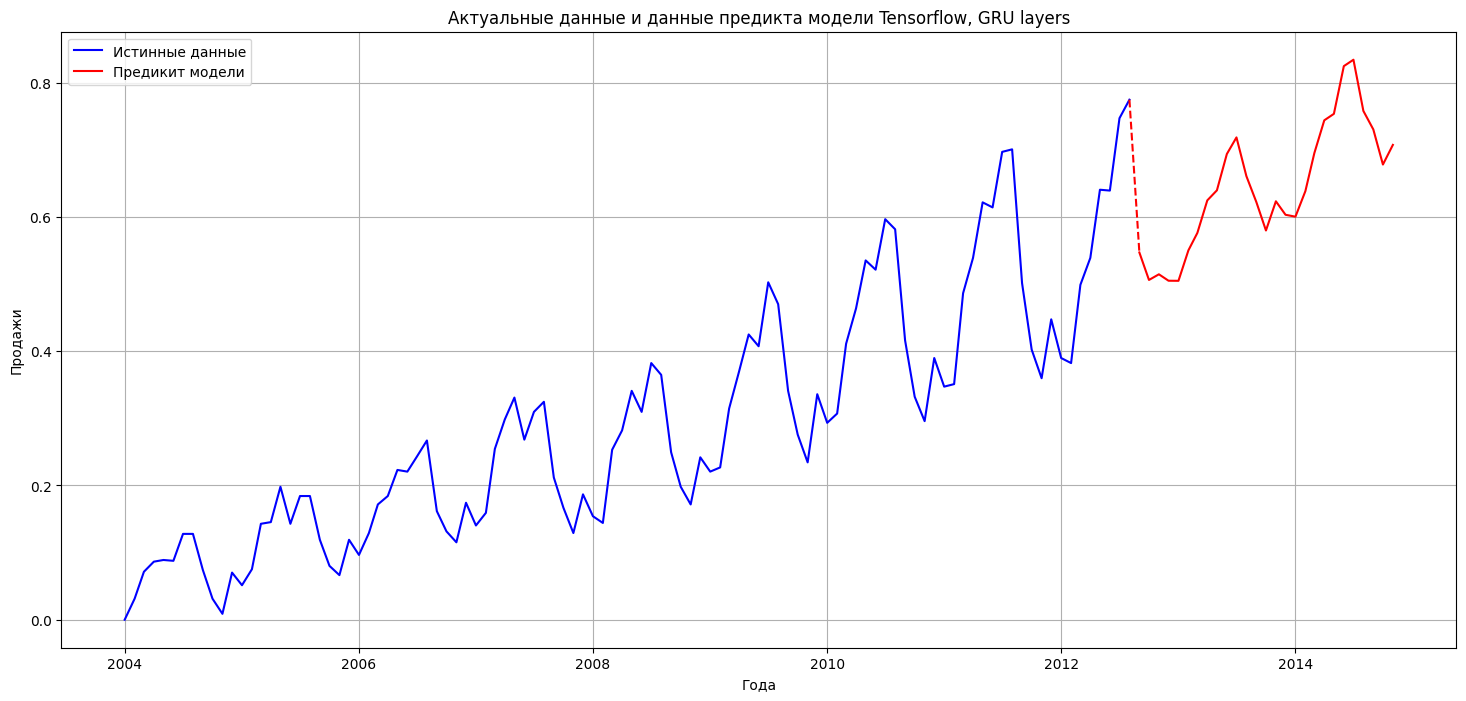

In [218]:
predict_model_gru_df = convert_predict_to_df(predict_keras_gru, x_test.index)
visual_actual_or_prediction(y_train, predict_model_gru_df, 'Tensorflow', 'GRU')

In [219]:
def keras_LSTM(x_tr,y_tr, x_tt ):

    
    stopping_ = keras.callbacks.EarlyStopping(
        monitor="mae",
        patience=10,
        mode = 'auto',
        restore_best_weights=True,
        verbose = 1
        
    )
    model = keras.Sequential([
        keras.layers.Input(shape=(x_tr.shape[1], 1)),
        keras.layers.LSTM(64),
        keras.layers.Dense(64,activation = 'relu'),
        keras.layers.Dense(32, activation = 'relu', kernel_regularizer= 'l2'),
        keras.layers.Dense(1)
    ])
    model.compile(optimizer = 'adam', loss = 'mse', metrics = ['mae'])

    history = model.fit(x_tr, y_tr, epochs = 100, batch_size = 32, 
        verbose = 0, callbacks = [stopping_])

    predict= model.predict(x_tt, verbose = 0)

    return model, history ,predict
    
model_keras_LSTM, history_LSTM, predict_keras_LSTM = keras_LSTM(x_train, y_train, x_test)


Epoch 39: early stopping
Restoring model weights from the end of the best epoch: 29.


In [231]:
mae_keras_LSTM = mean_absolute_error(predict_keras_LSTM, y_test)
mse_kears_LSTM = mean_squared_error(predict_keras_LSTM, y_test)

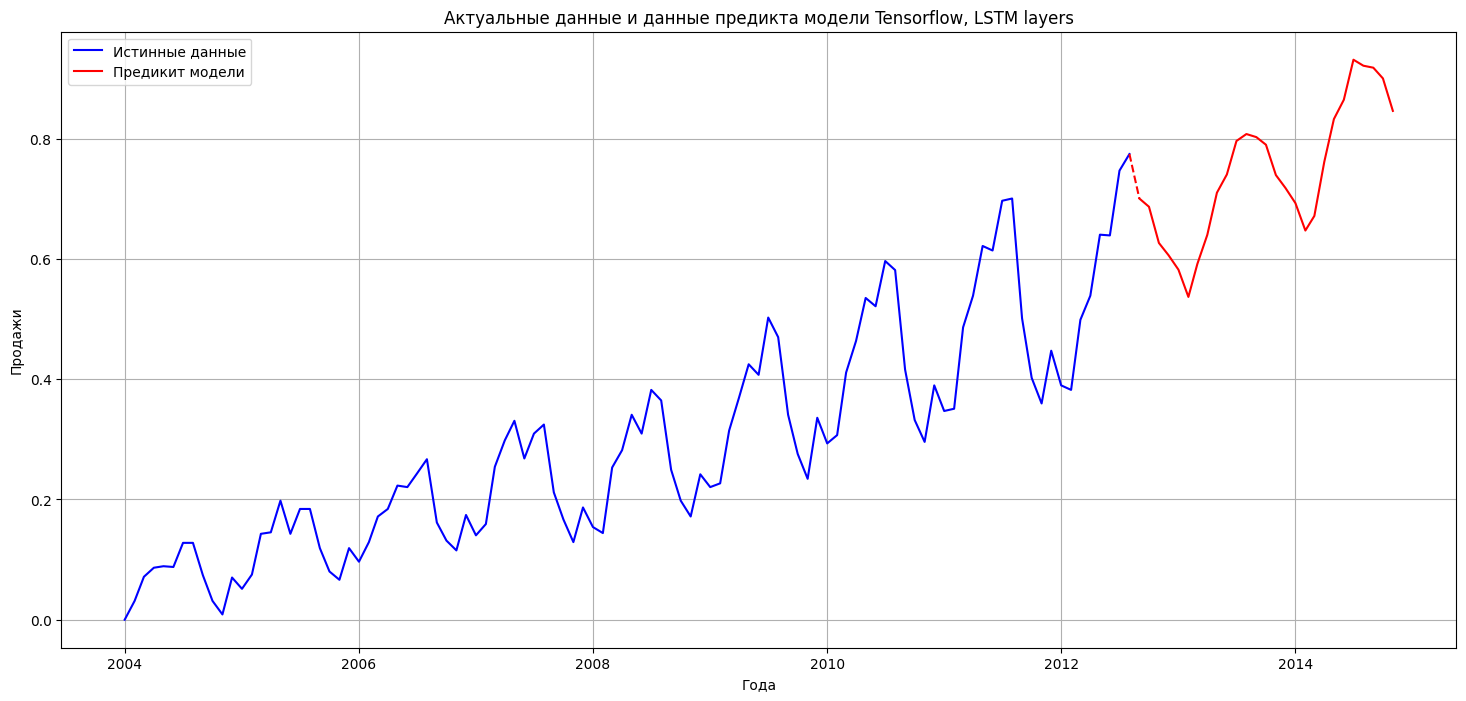

In [220]:
predict_model_lstm_df = convert_predict_to_df(predict_keras_LSTM, x_test.index)
visual_actual_or_prediction(y_train, predict_model_lstm_df, 'Tensorflow', 'LSTM')

In [241]:
def keras_RNN(x_tr,y_tr, x_tt ):

    
    stopping_ = keras.callbacks.EarlyStopping(
        monitor="mae",
        patience=10,
        mode = 'auto',
        restore_best_weights=True,
        verbose = 1
        
    )
    model = keras.Sequential([
        keras.layers.Input(shape=(x_tr.shape[1], 1)),
        keras.layers.SimpleRNN(32),
        keras.layers.Dense(64,activation = 'relu'),
        keras.layers.Dense(32, activation = 'relu', kernel_regularizer= 'l2'),
        keras.layers.Dense(1)
    ])
    model.compile(optimizer = 'adam', loss = 'mse', metrics = ['mae'])

    history = model.fit(x_tr, y_tr, epochs = 100, batch_size = 32, 
        verbose = 0, callbacks = [stopping_])

    predict= model.predict(x_tt, verbose = 0)

    return model, history ,predict
    
model_keras_RNN, history_RNN, predict_keras_RNN = keras_RNN(x_train, y_train, x_test)


Epoch 93: early stopping
Restoring model weights from the end of the best epoch: 83.


In [232]:
mae_keras_RNN = mean_absolute_error(predict_keras_RNN, y_test)
mse_kears_RNN = mean_squared_error(predict_keras_RNN, y_test)

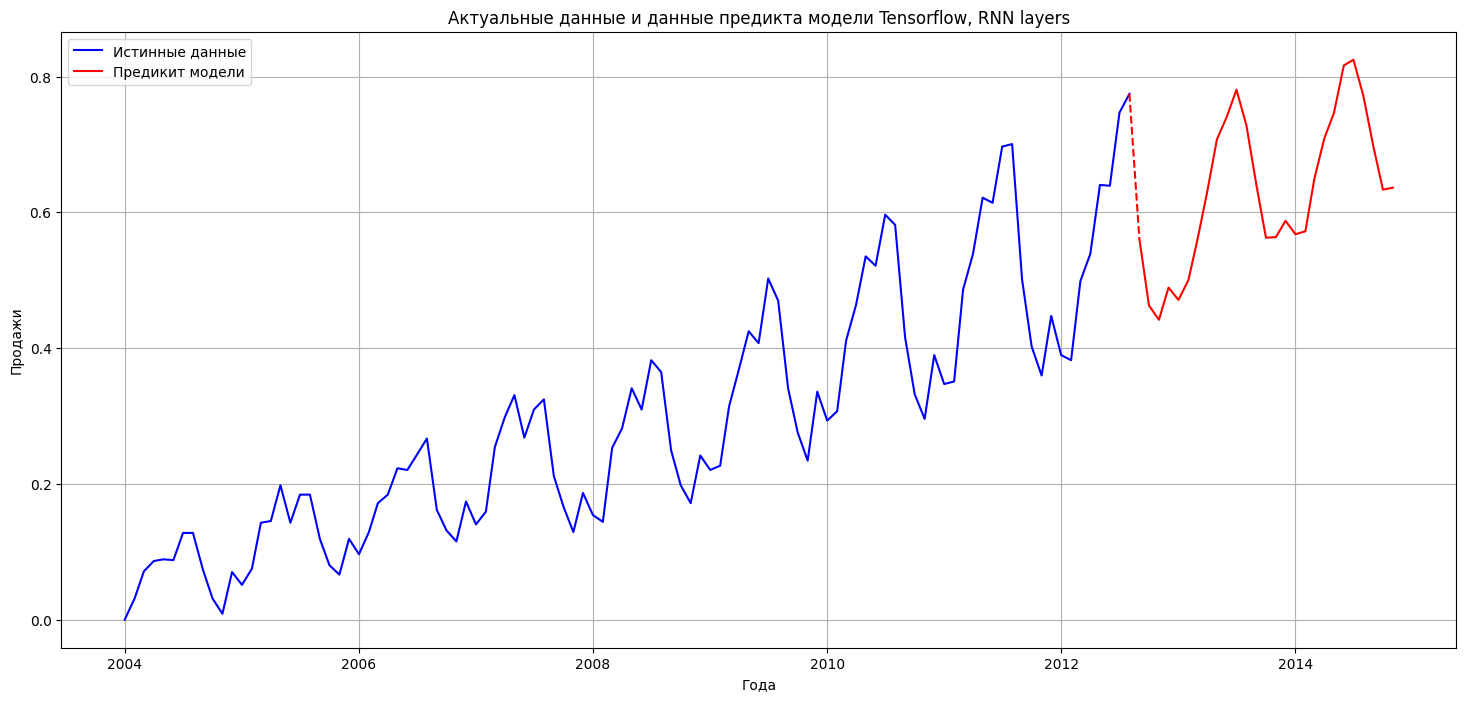

In [242]:
predict_model_rnn_df = convert_predict_to_df(predict_keras_RNN, x_test.index)
visual_actual_or_prediction(y_train, predict_model_rnn_df, 'Tensorflow', 'RNN')

In [298]:
x_train_np = np.array(x_train, dtype = np.float32)
y_train_np = np.array(y_train, dtype = np.float32)

In [299]:
x_train_tensor, y_train_tensor = torch.tensor(x_train_np),torch.tensor(y_train_np)
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

In [300]:
train_loader = DataLoader(train_dataset, batch_size = 16, shuffle = False)

In [310]:
x_test_np = np.array(x_test, dtype = np.float32)
y_test_np = np.array(y_test, dtype = np.float32)
x_test_tensor, y_test_tensor = torch.tensor(x_test_np),torch.tensor(y_test_np)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size = 16, shuffle = False)

In [304]:
class torch_gru(nn.Module):
    def __init__(self,input_size = x_train.shape[1]):
        super(torch_gru, self).__init__()
        self.sloi_gru = nn.GRU(input_size, 64)
        self.sloi1 = nn.Linear(64, 32)
        self.activation = nn.ReLU()
        self.sloi2 = nn.Linear(32, 1)

    def forward(self, x):
        out, _ = self.sloi_gru(x)
        out = self.sloi1(out)
        out = self.activation(out)
        out = self.sloi2(out)
        return out

torch_gru_model = torch_gru()
lert = 0.001
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(torch_gru_model.parameters(), lr = lert)

In [336]:
def train_load(loader, model, optimizer, loss_fn):
    model.train()
    n_epoch = 20

    for epoch in range(n_epoch):
        for i, (batch, label) in enumerate(loader):
            pred = model(batch)

            loss = loss_fn(pred, label)

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

In [337]:
def test_load(loader, model, loss_fn, optimizer):
    true_labels = []
    predicted_labels = []
    
    model.eval()  
    with torch.no_grad():  
        for i, (batch, label) in enumerate(test_loader):
            pred = model(batch)
            true_labels.extend(label.cpu().numpy())
            predicted_labels.extend(pred.cpu().numpy())
    return true_labels,predicted_labels

In [338]:
train_load(train_loader, torch_gru_model, optimizer, loss_fn )

In [339]:
true_label_gru, predict_label_gru = test_load(test_loader, torch_gru_model, optimizer, loss_fn )

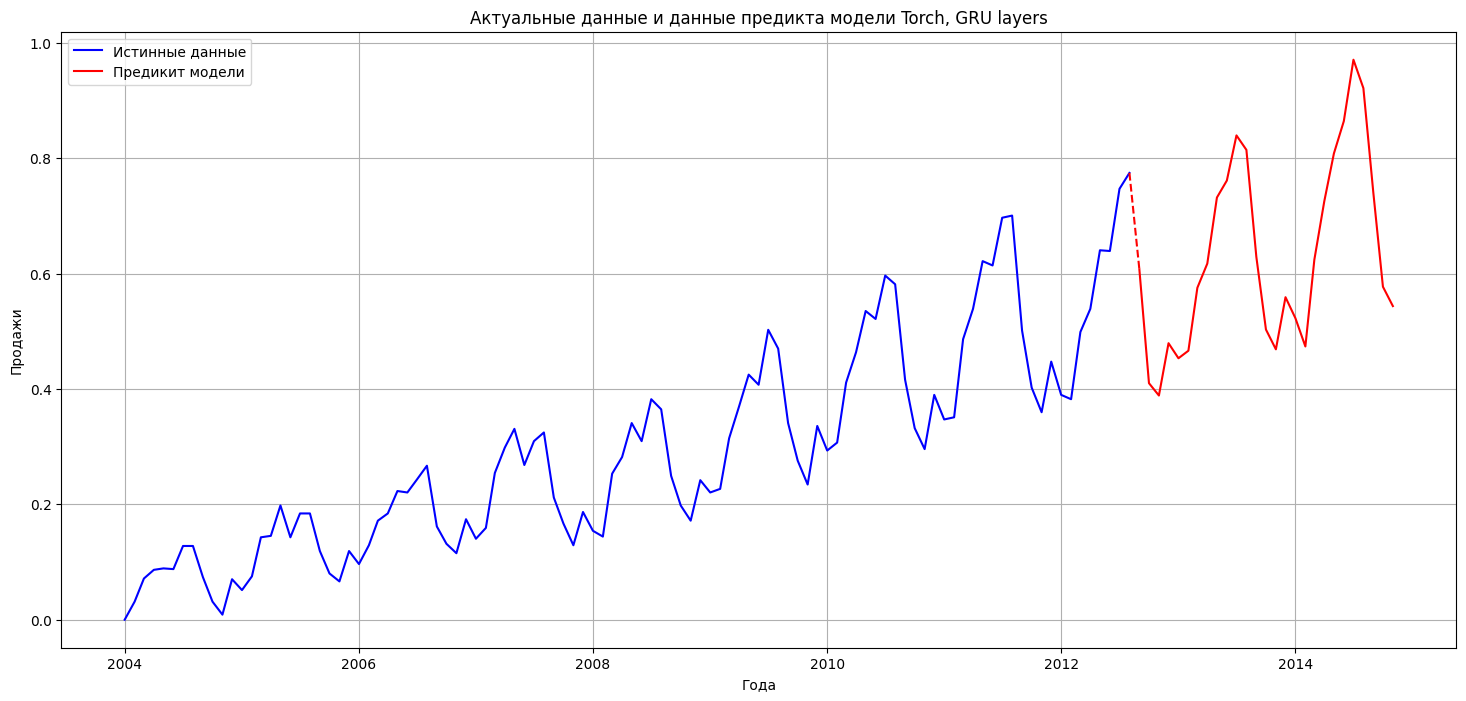

In [340]:
predict_torch_gru_df = convert_predict_to_df(predict_label_gru, x_test.index)
visual_actual_or_prediction(y_train, predict_torch_gru_df, 'Torch', 'GRU')

In [332]:
class torch_LSTM(nn.Module):
    def __init__(self,input_size = x_train.shape[1]):
        super(torch_LSTM, self).__init__()
        self.sloi_gru = nn.LSTM(input_size, 64)
        self.sloi1 = nn.Linear(64, 32)
        self.activation = nn.ReLU()
        self.sloi2 = nn.Linear(32, 1)

    def forward(self, x):
        out, _ = self.sloi_gru(x)
        out = self.sloi1(out)
        out = self.activation(out)
        out = self.sloi2(out)
        return out

torch_lstm_model = torch_LSTM()
lert = 0.001
loss_fn = nn.MSELoss()
optimizer_lstm = torch.optim.Adam(torch_lstm_model.parameters(), lr = lert)

In [341]:
train_load(train_loader, torch_lstm_model, optimizer_lstm, loss_fn )

In [342]:
true_label_lstm, predict_label_lstm = test_load(test_loader, torch_lstm_model, optimizer_lstm, loss_fn )

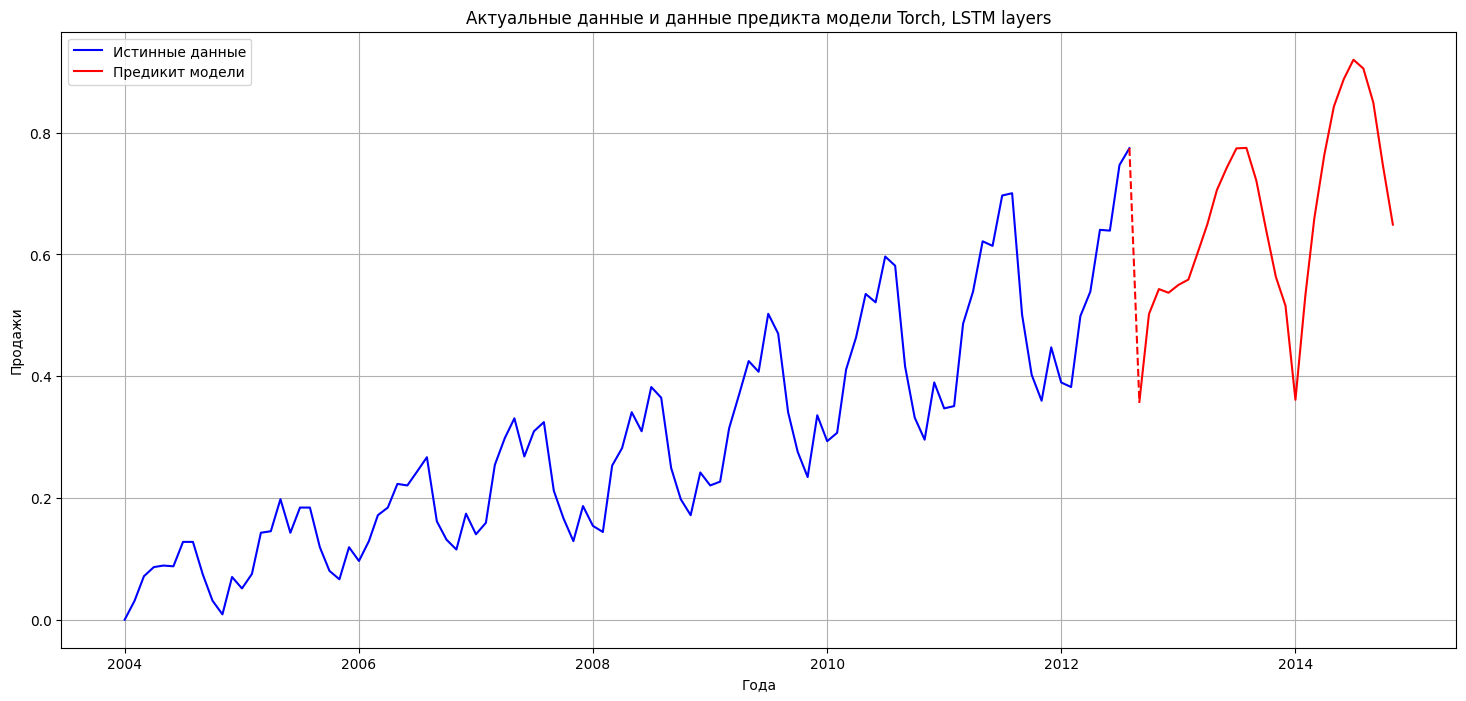

In [343]:
predict_torch_lstm_df = convert_predict_to_df(predict_label_lstm, x_test.index)
visual_actual_or_prediction(y_train, predict_torch_lstm_df, 'Torch', 'LSTM')

In [347]:
class torch_RNN(nn.Module):
    def __init__(self,input_size = x_train.shape[1]):
        super(torch_RNN, self).__init__()
        self.sloi_gru = nn.RNN(input_size, 64)
        self.sloi1 = nn.Linear(64, 32)
        self.activation = nn.ReLU()
        self.sloi2 = nn.Linear(32, 1)

    def forward(self, x):
        out, _ = self.sloi_gru(x)
        out = self.sloi1(out)
        out = self.activation(out)
        out = self.sloi2(out)
        return out

torch_rnn_model = torch_RNN()
lert = 0.001
loss_fn = nn.MSELoss()
optimizer_rnn = torch.optim.Adam(torch_rnn_model.parameters(), lr = lert)

In [348]:
train_load(train_loader, torch_rnn_model, optimizer_rnn, loss_fn )

In [349]:
true_label_rnn, predict_label_rnn = test_load(test_loader, torch_rnn_model, optimizer_rnn, loss_fn )

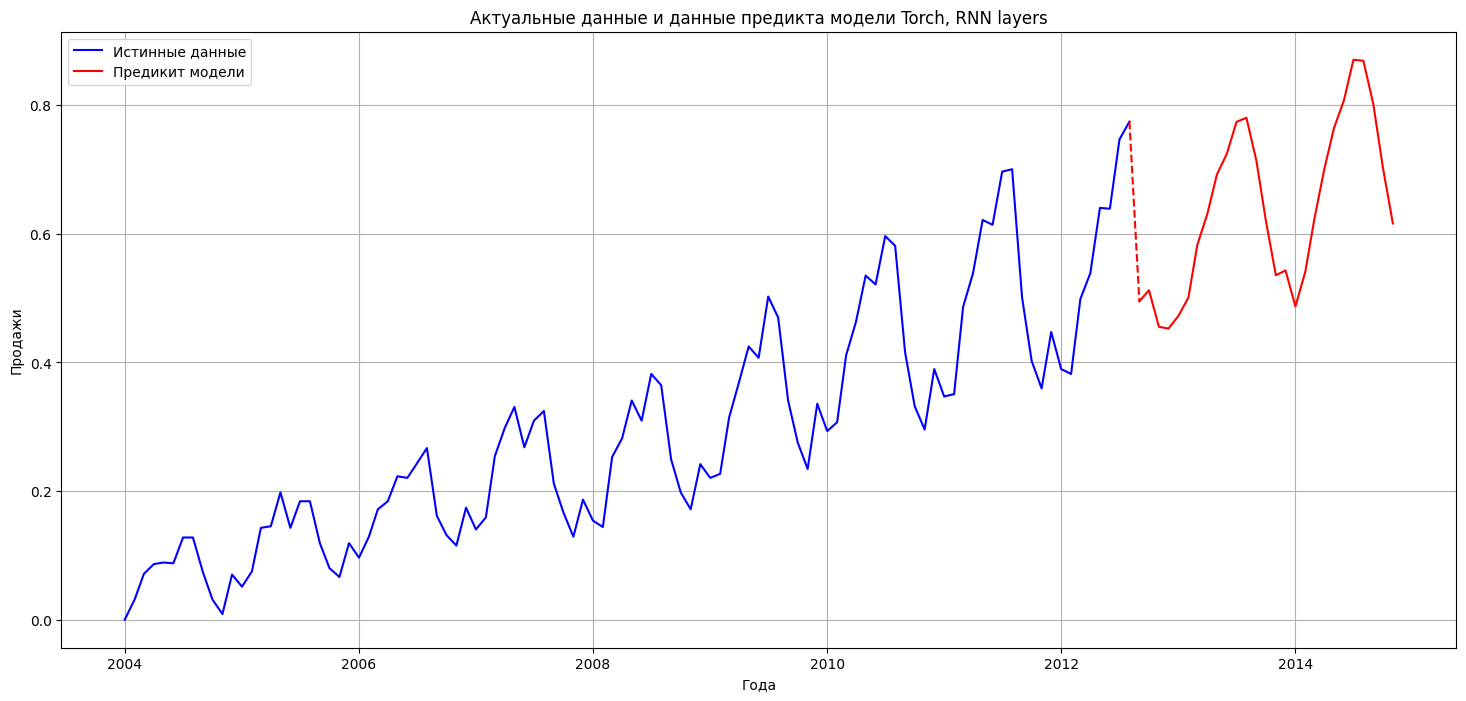

In [350]:
predict_torch_rnn_df = convert_predict_to_df(predict_label_rnn, x_test.index)
visual_actual_or_prediction(y_train, predict_torch_rnn_df, 'Torch', 'RNN')